In [1]:
import hoda
import tensorly as tl
import mne
%load_ext autoreload
%autoreload 2

!pip install line_profiler
%load_ext line_profiler
    
mne.set_log_level('ERROR')
tl.get_backend()


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
  Obtaining dependency information for line_profiler from https://files.pythonhosted.org/packages/43/61/534f034efa3aa01cf3855a37e7d2beee8df39d85e9b1e1302dc011bedcd6/line_profiler-4.1.3-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 717.6/717.6 kB 4.3 MB/s eta 0:00:00a 0:00:01

[notice] A new release of pip is available: 23.2.1 -> 24.0
[notice] To update, run: python3 -m pip install --upgrade pip


'cupy'

In [43]:
from moabb.paradigms import P300, MotorImagery
from moabb.datasets import *
from mne.decoding import Scaler

paradigm = P300(resample=128)
dataset = BNCI2014009()

"""
fmin = 8
fmax = 30
sfreq = 128
paradigm = MotorImagery(resample=sfreq, fmin=fmin, fmax=fmax,  n_classes=None)
dataset=  BNCI2014_001()
"""

epochs, labels, meta = paradigm.get_data(dataset=dataset, 
                                         subjects=[1],
                                         return_epochs=True)
session = meta['session'][0]
idc = meta['session'] == session
epochs = epochs[idc]
labels = labels[idc]
meta = meta[idc]

epochs._data = Scaler(scalings='mean', with_mean=True).fit_transform(epochs._data)

BNCI2014009 has been renamed to BNCI2014_009. BNCI2014009 will be removed in version 1.1.
The dataset class name 'BNCI2014009' must be an abbreviation of its code 'BNCI2014-009'. See moabb.datasets.base.is_abbrev for more information.


In [44]:
epochs

Number of events,576
Events,NonTarget: 480Target: 96
Time range,0.000 – 0.797 s
Baseline,off


In [45]:
import tensorly.decomposition
import matplotlib.pyplot as plt
import tensorly as tl
from hoda.tensorize import STFTensor
import numpy as np

nfreqs=16

X = epochs.get_data()
"""
tensor =  STFTensor(sfreq=sfreq, tmin=paradigm.tmin,
            morlet_params=dict(freqs=np.linspace(fmin, fmax, nfreqs)),
            #baseline_params=dict(baseline=(-.15,-.05),mode='logratio'),
            decim=8
)
X = tensor.fit_transform(X)
"""
y = labels

X.shape

(576, 16, 103)

In [56]:
from hoda.hoda import HODA, f_multiway,trunc_eigh
from hoda.backend import lobpcg
import cupyx.scipy.sparse.linalg
import warnings

from hoda.hoda import mode_scatter
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from hoda.classification import Vectorize
from sklearn.feature_selection import SelectFwe
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import pandas as pd

hoda = HODA(
        rank=1,
        max_iter=256,
        tol=1e-12,
        init ='random',
        shrinkage='lw',
        toeplitz=None,
        obj='rt',
        solver='lanczos',
        taper=True,
        extra_train_info=True,
        verbose=True,
        delta=None,
        ortho=False,
        fit_forward=True,
        random_state=42,

)

hoda.fit(X,y)

  0%|          | 0/256 [00:00<?, ?it/s]

  0%|          | 0/256 [00:00<?, ?it/s]

MSE: 0.9798117185874129 corr: 0.0037997151512920197
MSE: 0.9768181452786605 corr: 0.0025335596991240524
MSE: 0.9767805813085401 corr: 0.002552190091140944
MSE: 0.9767805416602414 corr: 0.002553386583489358
MSE: 0.9767805415984689 corr: 0.0025534282654208116


HODA(extra_train_info=True, fit_forward=True, init='random', random_state=42,
     rank=1, taper=True, tol=1e-12, verbose=True)

In [57]:
import pandas as pd
df = pd.DataFrame(hoda.train_info_)
df

,iteration,mode,update,shrinkage,rank,objective,F_tr,F_rt
0,1,0,1.056124e-01,0.004960,1,0.081881,0.107340,0.000373
1,1,1,9.209183e-03,0.056335,1,0.348189,0.398748,0.001385
2,2,0,2.116559e-02,0.005001,1,0.451976,0.552916,0.001920
3,2,1,4.103264e-03,0.053082,1,0.750391,0.841851,0.002923
4,3,0,4.240047e-02,0.005155,1,0.968690,1.183378,0.004109
5,3,1,3.588524e-02,0.056875,1,1.261081,1.405669,0.004881
6,4,0,7.434006e-03,0.005186,1,1.220284,1.533555,0.005325
7,4,1,3.660796e-04,0.059609,1,1.407842,1.570122,0.005452
8,5,0,6.675519e-04,0.005327,1,1.251832,1.589108,0.005518
9,5,1,4.315324e-05,0.060124,1,1.428322,1.593964,0.005535


<Axes: xlabel='iteration', ylabel='rank'>

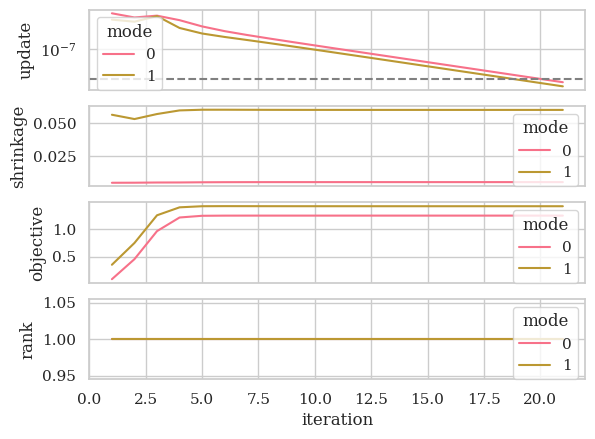

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt
fig, axs = plt.subplots(4,1, sharex=True)
sns.lineplot(data=df, x='iteration', y='update',hue='mode', ax=axs[0])
axs[0].axhline(hoda.tol, color='grey', linestyle='--')
axs[0].set_yscale('log')
sns.lineplot(data=df, x='iteration', y='shrinkage',hue='mode', ax=axs[1])
sns.lineplot(data=df, x='iteration', y='objective',hue='mode', ax=axs[2])
sns.lineplot(data=df, x='iteration', y='rank',hue='mode', ax=axs[3])

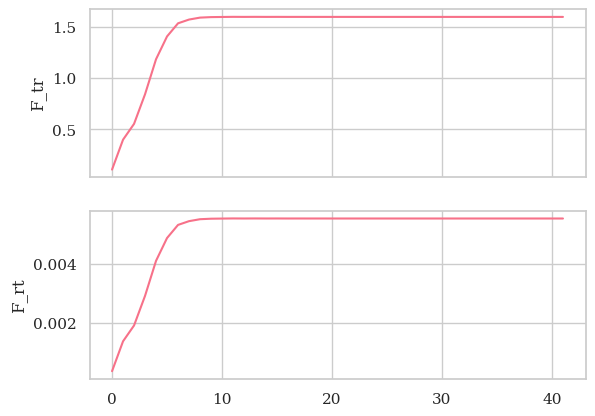

In [59]:
if hoda.extra_train_info:
    fig, axs = plt.subplots(2,1, sharex=True)
    sns.lineplot(data=df, x=df.index, y='F_tr', ax=axs[0])
    sns.lineplot(data=df, x=df.index, y='F_rt', ax=axs[1])



In [60]:
import math
from hoda.util import center

X = tl.tensor(X)
G = hoda.transform(X)
X_approx = hoda.inv_transform(G)
err = X-X_approx


0.0025534282654208116
0.9767805415984689


<Axes: >

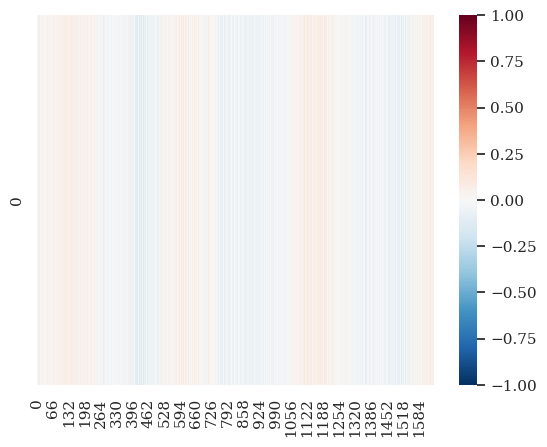

In [61]:
n_samples = X.shape[0]
G_flat = tl.to_numpy(G.reshape((n_samples, -1), order='F'), )
err_flat = tl.to_numpy(err.reshape((n_samples, -1), order='F'))
cross_corr = np.corrcoef(G_flat, err_flat, rowvar=False)
cross_corr = cross_corr[G_flat.shape[-1]:,:G_flat.shape[-1]].T
print(tl.metrics.regression.MSE(cross_corr,0))
print(tl.metrics.regression.MSE(X,X_approx))

sns.heatmap(cross_corr,  cmap='RdBu_r', center=0, vmin=-1, vmax=1)

0.25178280046356405


<Axes: >

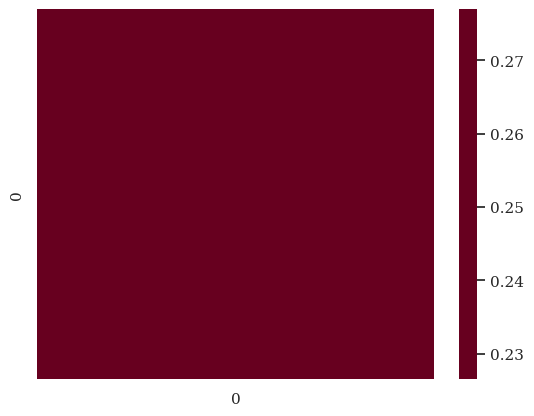

In [62]:
#G_cov = tl.tensordot(G.T, G, axes=1)/(n_samples-1)
G_flat = G.reshape(n_samples, -1)
G_cov = G_flat.T@G_flat/(n_samples -1)
print(tl.norm(G_cov))
sns.heatmap(tl.to_numpy(G_cov),  cmap='RdBu_r', center=0)

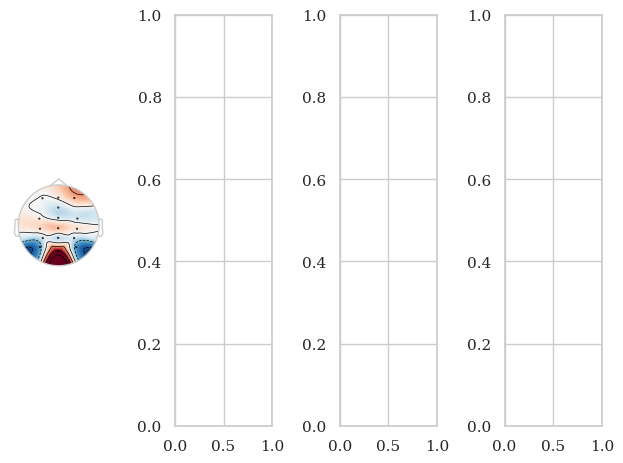

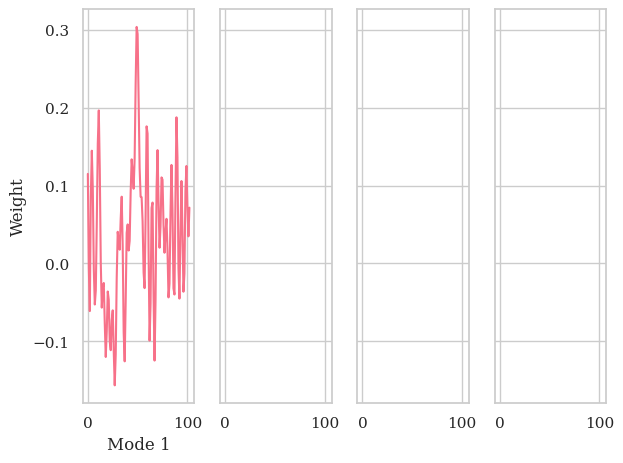

In [63]:
import numpy as np
from mne.viz import plot_topomap
import matplotlib.pyplot as plt
import tensorly as tl

col_wrap = 4


n_col = col_wrap
n_row = int( np.ceil(hoda.rank_[0] / col_wrap)) 
fig, axs = plt.subplots(n_row, n_col, layout='tight')
vmax = float(tl.max(tl.abs(hoda.weights_[0])))
for i in range(hoda.rank_[0]):
    w = tl.to_numpy(hoda.weights_[0][:,i])
    plot_topomap(w, epochs.info, axes=axs.flatten()[i], show=False, vlim=[-vmax, vmax])

order = X.ndim-1
for k in range(1, order):
    n_row = int( np.ceil(hoda.rank_[k] / col_wrap)) 
    fig, axs = plt.subplots(n_row, n_col,  layout='tight', sharex=True, sharey=True)
    for i in range(hoda.rank_[k]):
        w = tl.to_numpy(hoda.weights_[k][:,i])
        axs.flatten()[i].plot(w)
        axs.flatten()[i].set_xlabel(f'Mode {k}')
        axs.flatten()[i].sharey(axs.flatten()[0])
    axs.flatten()[0].set_ylabel('Weight');


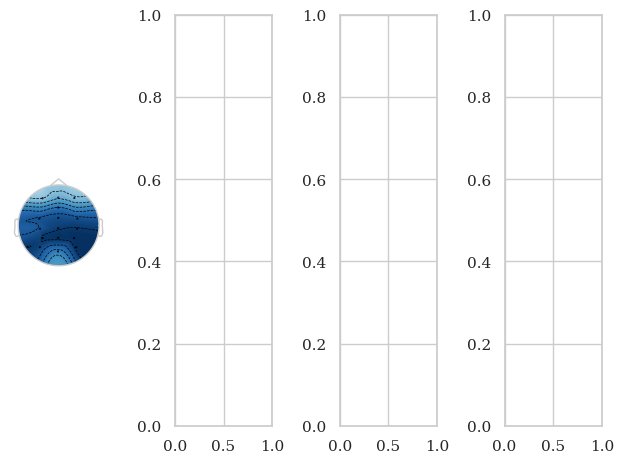

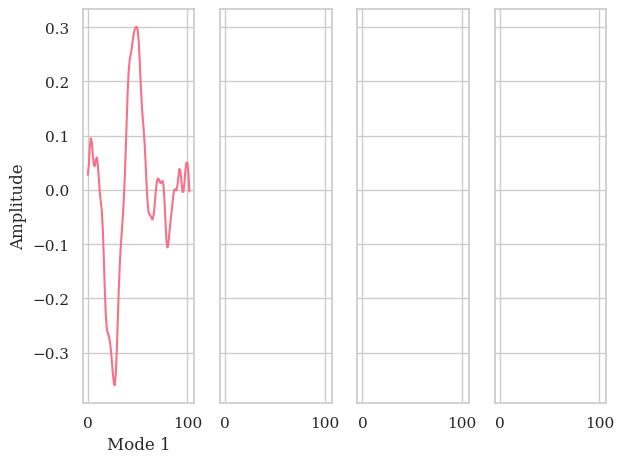

In [64]:

n_row = int(np.ceil(hoda.rank_[0] / col_wrap)) 
fig, axs = plt.subplots(n_row, n_col, layout='tight')
A = hoda.aps_[0]
vmax = float(tl.max(tl.abs(A)))
for i in range(hoda.rank_[0]):
    a = tl.to_numpy(A[:,i])
    plot_topomap(a, epochs.info, axes=axs.flatten()[i], show=False, vlim=[-vmax, vmax])

for k in range(1, order):
    n_row = int(np.ceil(hoda.rank_[k] / col_wrap)) 
    fig, axs = plt.subplots(
        n_row, n_col, 
        layout='tight', 
        sharex=True,
        sharey=True
    )
    A = hoda.aps_[k]
    for i in range(hoda.rank_[k]):
        a = tl.to_numpy(A[:,i])
        axs.flatten()[i].plot(a)
        axs.flatten()[i].set_xlabel(f'Mode {k}')
        axs.flatten()[i].sharey(axs.flatten()[0])
    axs.flatten()[0].set_ylabel('Amplitude');


In [65]:
Xt = hoda.transform(X)

[[3.64711888e-81]]


<BarContainer object of 1 artists>

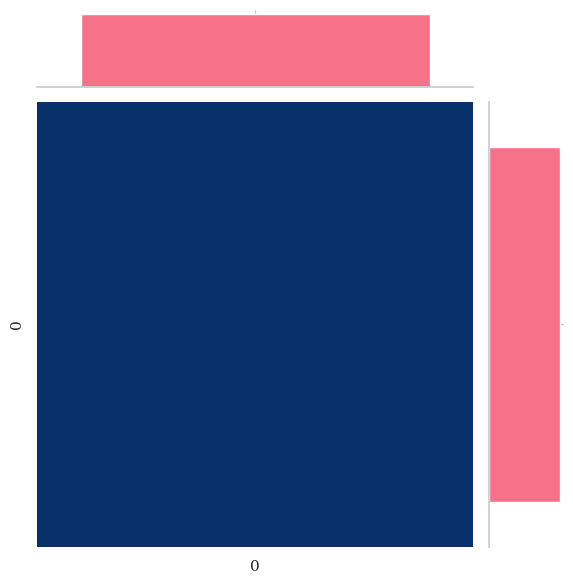

In [66]:
from hoda.util import f_multiway, f_oneway

F, p = f_oneway(Xt,y)

classes = np.unique(y)
y_like_Xt = tl.zeros_like(Xt)
for ci, c in enumerate(classes):
    y_like_Xt[y==c] = ci


F_sp, p_sp = f_oneway(tl.unfold(Xt, 0+1).T, tl.unfold(y_like_Xt, 0+1).T[:,0])
F_tmp, p_tmp = f_oneway(tl.unfold(Xt, 1+1).T, tl.unfold(y_like_Xt, 1+1).T[:,0])


F_sp = tl.to_numpy(F_sp)
F_tmp = tl.to_numpy(F_tmp)
F = tl.to_numpy(F)
p= tl.to_numpy(p)
print(p)
g = sns.JointGrid()
sns.heatmap(F, vmin=0, ax=g.ax_joint, mask=p>0.5/p.size,cbar=False, cmap='Blues')
g.ax_marg_x.bar(np.arange(p.shape[1]) + 0.5, F_tmp)
g.ax_marg_y.barh(np.arange(p.shape[0]) + 0.5, F_sp)



In [67]:
from sklearn.feature_selection import SelectFwe

Xt_flat = tl.to_numpy(Xt.reshape((Xt.shape[0], -1)))
Xt_flat.shape

(576, 1)

In [68]:

from sklearn.manifold import TSNE
import math
from sklearn.decomposition import PCA
import re, seaborn as sns
import numpy as np
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import ListedColormap

Xt_flat = tl.to_numpy(Xt.reshape((Xt.shape[0], -1)))

if Xt_flat.shape[-1] > 1:
    n_components = 2
    decomp  = PCA(n_components=n_components, whiten=True)
    Xt_viz = decomp.fit_transform(tl.to_numpy(Xt_flat))
    
    cmap = {'Target': '#e28743', 'NonTarget': '#1e81b0'}
    c = np.vectorize(cmap.get)(y)    
    fig, ax = plt.subplots(1,1)
    ax.scatter(Xt_viz[:,0], Xt_viz[:,1], c=c)
    ax.set_aspect('equal')

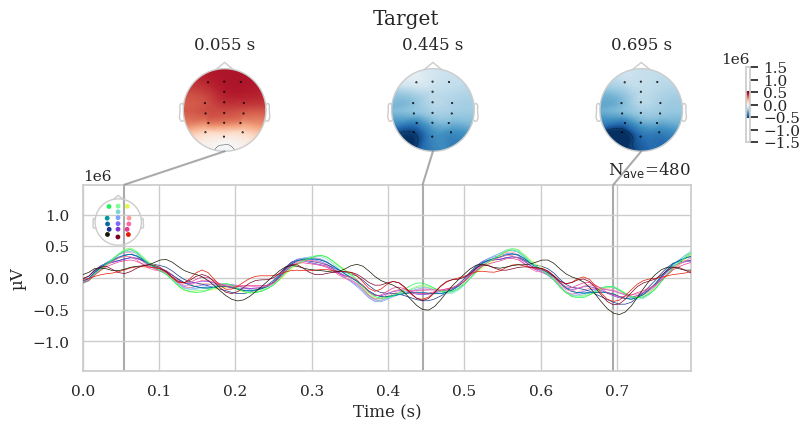

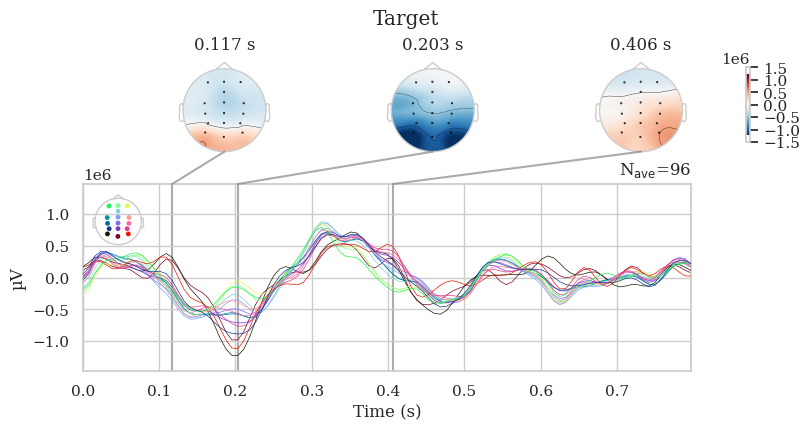

In [69]:
import numpy as np

evokeds = []
vmax=0
for cls in np.unique(labels):
    evoked = epochs[cls].average()
    evokeds.append(evoked)
    vmax= max(vmax, np.max(np.abs(evoked.data))*1.2*1e6)

ts_args=dict(ylim=dict(eeg=[-vmax,vmax]))
joint_args=dict(ts_args=ts_args)

for evoked  in evokeds:
    if len(evoked.ch_names) > 1:
        evoked.plot_joint(title=cls, **joint_args)
    else:
        evoked.plot(**ts_args)

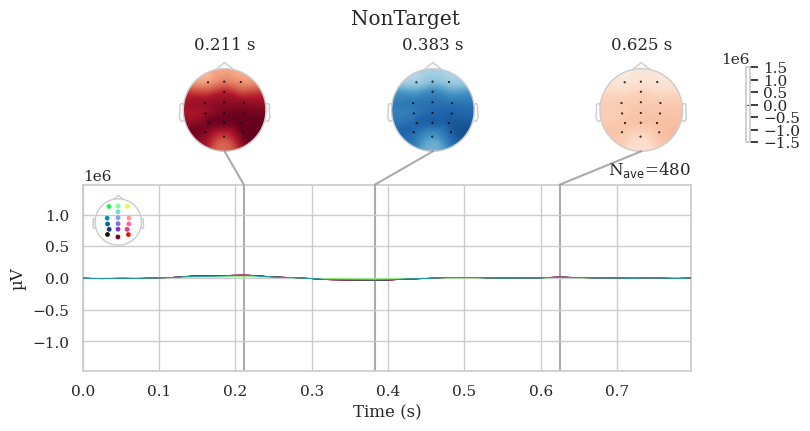

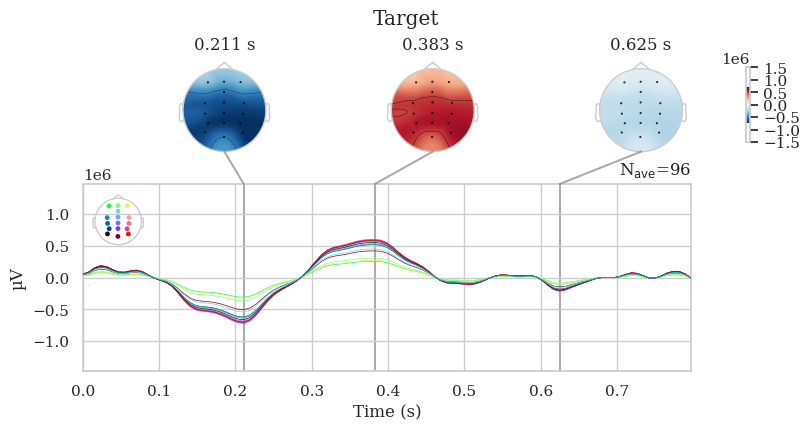

In [70]:
epochs_rec = epochs.copy()
epochs_rec._data = tl.to_numpy(hoda.inv_transform(hoda.transform(epochs.get_data())))
evokeds_rec = []
for cls in np.unique(labels):
    evoked_rec = epochs_rec[cls].average()
    evokeds_rec.append(evoked_rec)
    if len(evoked_rec.ch_names) > 1:
        evoked_rec.plot_joint(title=cls,
                              **joint_args
                             )
    else:
        evoked_rec.plot(**ts_args)

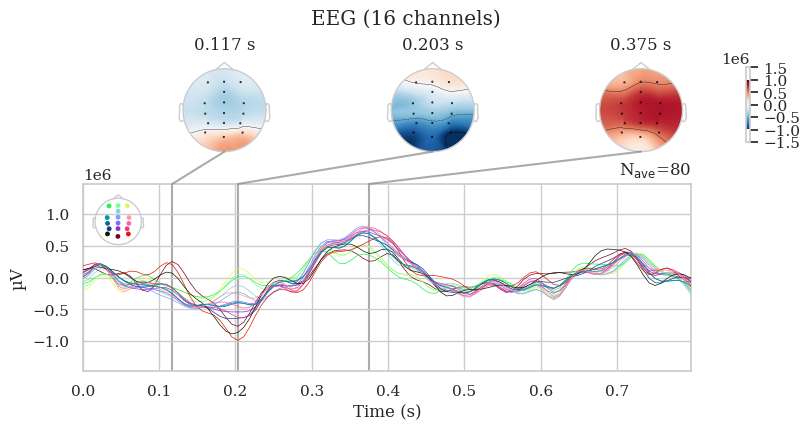

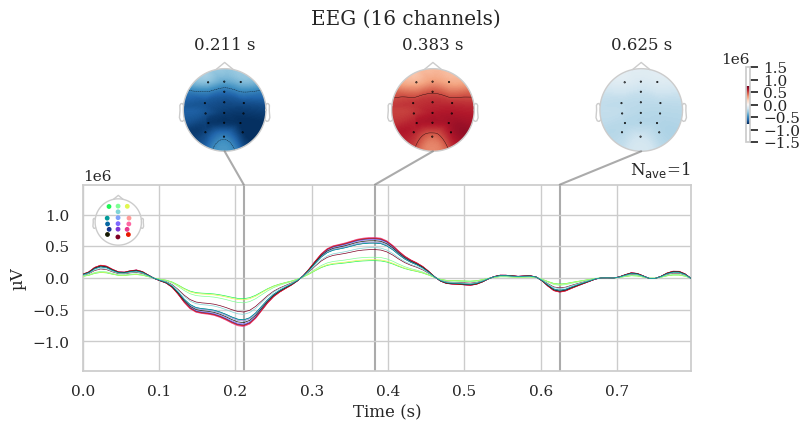

In [71]:
from mne import combine_evoked, EvokedArray

contrast = combine_evoked(evokeds, weights=[-1,1])
_ = contrast.plot_joint(
    **joint_args
)



means_rec = hoda.inv_transform(hoda.transform(hoda.means_))
contrast_rec = means_rec[1]-means_rec[0]
contrast_rec = EvokedArray(tl.to_numpy(contrast_rec), epochs.info, epochs.tmin)
_ = contrast_rec.plot_joint(
    **joint_args
)

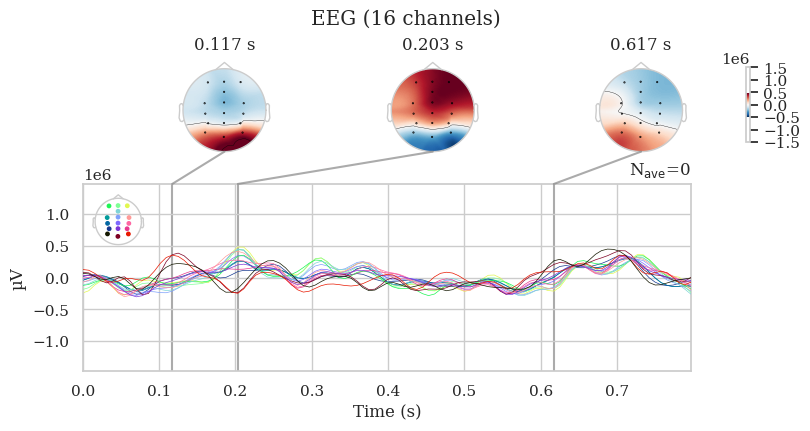

In [72]:
rec_diff = combine_evoked([contrast, contrast_rec], weights=[1,-1])
_ = rec_diff.plot_joint(
    **joint_args
)